In [45]:
print("Predictive Maintenance Project Started")

Predictive Maintenance Project Started


In [46]:
import pandas as pd
import numpy as np

In [47]:
data = pd.read_csv("../data/maintenance_data.csv")

In [48]:
data.head()

,equipment_id,equipment_type,runtime_hours,temperature,fault_count_30_days,downtime_minutes_30_days,days_since_last_pm,sensor_reading,throughput_rate,failure_next_7_days,fault_type
0,EQ_0001,conveyor,910,84.52,2,87,117,40.77,1623,0,none
1,EQ_0002,conveyor,2969,71.03,2,235,89,42.12,2084,1,motor_fault
2,EQ_0003,sorter,524,65.85,2,174,62,54.71,1062,0,none
3,EQ_0004,sorter,1949,108.71,0,306,7,55.91,520,1,sensor_fault
4,EQ_0005,conveyor,2938,70.79,2,263,47,45.62,534,0,none


In [49]:
data.shape

(500, 11)

In [50]:
data.columns

Index(['equipment_id', 'equipment_type', 'runtime_hours', 'temperature',
       'fault_count_30_days', 'downtime_minutes_30_days', 'days_since_last_pm',
       'sensor_reading', 'throughput_rate', 'failure_next_7_days',
       'fault_type'],
      dtype='str')

In [51]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   equipment_id              500 non-null    str    
 1   equipment_type            500 non-null    str    
 2   runtime_hours             500 non-null    int64  
 3   temperature               500 non-null    float64
 4   fault_count_30_days       500 non-null    int64  
 5   downtime_minutes_30_days  500 non-null    int64  
 6   days_since_last_pm        500 non-null    int64  
 7   sensor_reading            500 non-null    float64
 8   throughput_rate           500 non-null    int64  
 9   failure_next_7_days       500 non-null    int64  
 10  fault_type                500 non-null    str    
dtypes: float64(2), int64(6), str(3)
memory usage: 53.0 KB


In [52]:
data.describe()

,runtime_hours,temperature,fault_count_30_days,downtime_minutes_30_days,days_since_last_pm,sensor_reading,throughput_rate,failure_next_7_days
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1549.838000,77.569020,2.962000,197.040000,60.128000,49.830740,1458.996000,0.266000
std,870.261555,12.436794,1.777322,110.817252,34.102868,15.443889,569.735779,0.442307
min,55.000000,36.260000,0.000000,2.000000,1.000000,1.410000,507.000000,0.000000
25%,733.500000,69.480000,2.000000,104.750000,32.000000,39.582500,976.000000,0.000000
50%,1584.500000,77.040000,3.000000,195.000000,61.000000,50.320000,1414.000000,0.000000
75%,2329.250000,84.737500,4.000000,286.000000,89.000000,60.625000,1960.250000,1.000000
max,2981.000000,116.240000,9.000000,399.000000,119.000000,97.900000,2498.000000,1.000000


In [53]:
data.isnull().sum()

equipment_id                0
equipment_type              0
runtime_hours               0
temperature                 0
fault_count_30_days         0
downtime_minutes_30_days    0
days_since_last_pm          0
sensor_reading              0
throughput_rate             0
failure_next_7_days         0
fault_type                  0
dtype: int64

In [54]:
data["failure_next_7_days"].value_counts()

failure_next_7_days
0    367
1    133
Name: count, dtype: int64

In [55]:
data["fault_type"].value_counts()

fault_type
none            367
sensor_fault     35
overheating      31
jam              27
belt_issues      22
motor_fault      18
Name: count, dtype: int64

In [56]:
data.groupby("failure_next_7_days")[[
    "runtime_hours",
    "temperature",
    "fault_count_30_days",
    "downtime_minutes_30_days",
    "days_since_last_pm",
    "sensor_reading",
    "throughput_rate",
]].mean()

,runtime_hours,temperature,fault_count_30_days,downtime_minutes_30_days,days_since_last_pm,sensor_reading,throughput_rate
failure_next_7_days,,,,,,,
0,1337.493188,76.139319,2.825613,184.782016,51.673025,50.481390,1463.029973
1,2135.781955,81.514135,3.338346,230.864662,83.458647,48.035338,1447.864662


<Axes: title={'center': 'Failure Prediction Count'}, xlabel='failure_next_7_days'>

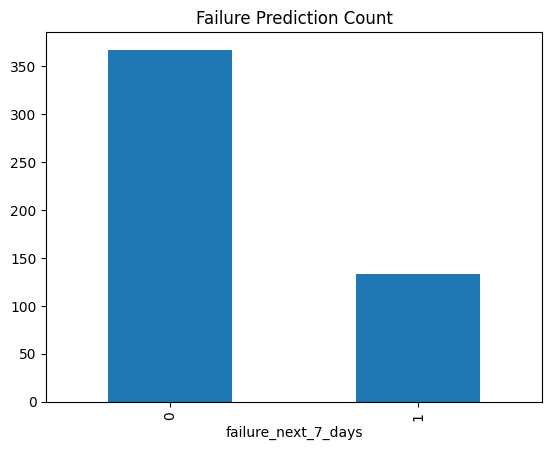

In [57]:
data["failure_next_7_days"].value_counts().plot(kind="bar", title="Failure Prediction Count")

<Axes: title={'center': 'temperature'}, xlabel='failure_next_7_days'>

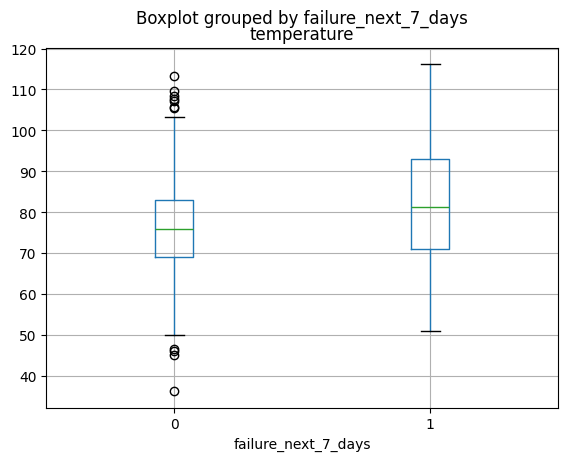

In [58]:
data.boxplot(column="temperature", by="failure_next_7_days")

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [60]:
features = [
    "runtime_hours",
    "temperature",
    "fault_count_30_days",
    "downtime_minutes_30_days",
    "days_since_last_pm",
    "sensor_reading",
    "throughput_rate",
]

target = "failure_next_7_days"

In [61]:
x = data[features]
y = data[target]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

In [63]:
failure_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
)

In [64]:
failure_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [65]:
y_pred = failure_model.predict(X_test)

In [66]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9


In [67]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        72
           1       0.88      0.75      0.81        28

    accuracy                           0.90       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.90      0.90      0.90       100



In [ ]:
confusion_matrix(
    y_test,
    y_pred
)

array([[69,  3],
       [ 7, 21]])

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
features = [
    "runtime_hours",
    "temperature",
    "fault_count_30_days",
    "downtime_minutes_30_days",
    "days_since_last_pm",
    "sensor_reading",
    "throughput_rate"
]

target = "failure_next_7_days"

In [14]:
X = data[features]
y = data[target]

NameError: name 'data' is not defined

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

NameError: name 'X' is not defined

In [7]:
failure_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

NameError: name 'RandomForestClassifier' is not defined

In [ ]:
failure_model.fit(X_train, y_train)

In [ ]:
y_pred = failure_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
confusion_matrix(y_test, y_pred)

In [4]:
import joblib
import os

In [5]:
os.makedirs("../models", exist_ok=True)

In [6]:
joblib.dump(failure_model, "../models/failure_prediction_model.pkl")

NameError: name 'failure_model' is not defined

In [ ]:
joblib.dump(features, "../models/failure_model_features.pkl")

In [ ]:
loaded_model = joblib.load("../models/failure_prediction_model.pkl")
loaded_features = joblib.load("../models/failure_model_features.pkl")

print("Model loaded successfully!")
print("Features:", loaded_features)

In [ ]:
sample_equipment = pd.DataFrame([{
    "runtime_hours": 2200,
    "temperature": 96,
    "fault_count_30_days": 7,
    "downtime_minutes_30_days": 240,
    "days_since_last_pm": 75,
    "sensor_reading": 72,
    "throughput_rate": 1200
}])

prediction = loaded_model.predict(sample_equipment)

print("Prediction:", prediction[0])

In [ ]:
if prediction[0] == 1:
    print("Failure Risk: HIGH - Maintenance should be scheduled soon.")
else:
    print("Failure Risk: LOW - No immediate maintenance action required.")